# Fase 2: Creación, Entrenamiento y Evaluación del Modelo CNN

## 1. Carga de los Datos Preprocesados
Comenzamos cargando los tensores unificados que generamos en la Fase 1. Gracias a nuestro procesamiento previo con OpenCV, estos datos ya integran las imágenes de nuestros datasets, estandarizadas a 64x64 píxeles en escala de grises.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar los datos desde la carpeta Dataset (subimos un nivel con '../')
X_train = np.load('../dataset/datos_procesados/X_train.npy')
X_val   = np.load('../dataset/datos_procesados/X_val.npy')
X_test  = np.load('../dataset/datos_procesados/X_test.npy')
Y_train = np.load('../dataset/datos_procesados/Y_train.npy')
Y_val   = np.load('../dataset/datos_procesados/Y_val.npy')
Y_test  = np.load('../dataset/datos_procesados/Y_test.npy')

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de validación: {X_val.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (12618, 64, 64, 1)
Dimensiones de validación: (2704, 64, 64, 1)
Dimensiones de prueba: (2704, 64, 64, 1)


## 2. Definición de la Arquitectura del Modelo (CNN)

Para este problema de clasificación de imágenes, utilizaremos una **Red Neuronal Convolucional (CNN)**. 

### Justificación de las Capas:
* **Conv2D (Capas Convolucionales):** Son el núcleo del modelo. Detectan características espaciales como bordes y formas de los dedos.
* **MaxPooling2D:** Reduce la dimensionalidad de la imagen, conservando las características más importantes detectadas por la convolución y evitando el sobreajuste.
* **Flatten:** Aplana la matriz bidimensional resultante en un vector unidimensional.
* **Dense (Capa Oculta - ReLU):** Capa con función de activación ReLU que introduce no-linealidad y evita el problema del desvanecimiento del gradiente.
* **Dropout & L2 (Regularización):** Apagamos aleatoriamente un 50% de las neuronas en cada iteración y penalizamos los pesos grandes (L2) para evitar el *Overfitting*.
* **Dense (Capa de Salida - Softmax):** Tiene 10 neuronas (una para cada dígito) que generan una distribución de probabilidad.

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

# Instanciar el modelo
model = Sequential()

# Bloque Convolucional 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(MaxPooling2D((2, 2)))

# Bloque Convolucional 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Bloque Convolucional 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Aplanamiento y Clasificación
model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001))) # Regularización L2
model.add(Dropout(0.5)) # Regularización Dropout (Apaga el 50% de neuronas)
model.add(Dense(10, activation='softmax')) # Salida de 10 clases

model.summary()

I0000 00:00:1783519591.985284   32376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783519591.985641   32376 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783519592.014462   32376 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783519592.852213   32376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Configuración y Callbacks (Early Stopping y TensorBoard)
Utilizaremos el optimizador Adam y la pérdida *Categorical Crossentropy*. Además, implementaremos **Early Stopping** (Punto 6 del taller) para detener el entrenamiento si el modelo deja de mejorar, y **TensorBoard** para monitoreo.

In [3]:
import os
import datetime
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

# Compilar modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Configurar TensorBoard (guardará los logs en la carpeta principal)
log_dir = os.path.join("../logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Configurar Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

## 4. Entrenamiento del Modelo con Pesos Balanceados (Class Weights)
Dado que fusionamos múltiples datasets, calculamos dinámicamente los pesos de cada clase para obligar a la red a "prestarle más atención" a los dígitos que tienen menos fotografías, evitando sesgos.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# 1. Calcular los pesos de las clases
y_integers = np.argmax(Y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
pesos_diccionario = dict(enumerate(class_weights))

# 2. Generador de imágenes (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1
)

batch_size = 32
epochs = 50

# 3. Entrenar el modelo
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    validation_data=(X_val, Y_val),
    epochs=epochs,
    class_weight=pesos_diccionario, # Balanceo de clases
    callbacks=[early_stop, tensorboard_callback],
    verbose=1
)

Epoch 1/50


I0000 00:00:1783519594.458955   32376 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5534 - loss: 1.3575 - val_accuracy: 0.8395 - val_loss: 0.6438
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7472 - loss: 0.8594 - val_accuracy: 0.8998 - val_loss: 0.4943
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7977 - loss: 0.7281 - val_accuracy: 0.9231 - val_loss: 0.4108
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8255 - loss: 0.6668 - val_accuracy: 0.9445 - val_loss: 0.3547
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8453 - loss: 0.6195 - val_accuracy: 0.9549 - val_loss: 0.3321
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8505 - loss: 0.6011 - val_accuracy: 0.9593 - val_loss: 0.3247
Epoch 7/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8702 - loss: 0.5484 - val_accuracy: 0.9660 - val_loss: 0.3021
Epoch 8/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8793 - loss: 0.5303 - val_accuracy: 0.969

## 5. Evaluación y Análisis de Resultados
Graficamos las curvas de aprendizaje y evaluamos con los datos de prueba (Test Data) que el modelo jamás ha visto.

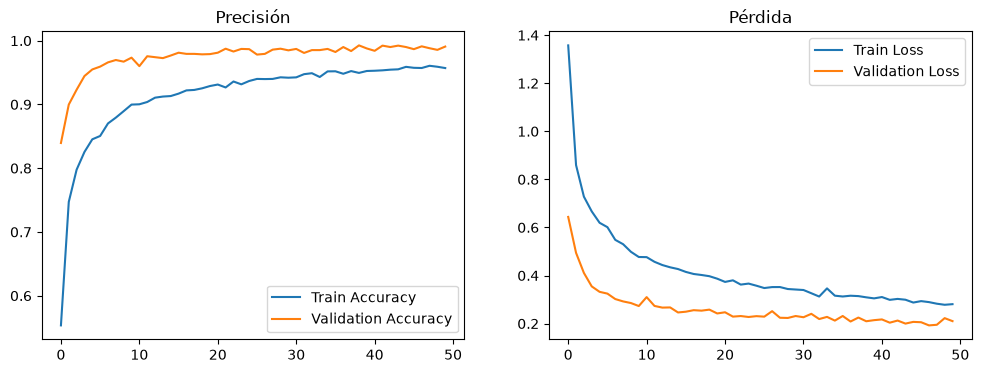

Precisión final en datos de PRUEBA: 99.11%


In [5]:
# Gráfica de Precisión y Pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Precisión')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Pérdida')
plt.show()

# Evaluación final en TEST
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Precisión final en datos de PRUEBA: {test_accuracy*100:.2f}%")

## 6. Exportación del Modelo para Web App
Guardamos el modelo para consumirlo con TensorFlow.js.

In [ ]:
# Crear carpeta si no existe
if not os.path.exists('../modelo_final/'):
    os.makedirs('../modelo_final/')

ruta_modelo = '../modelo_final/modelo_cnn_sign_language.keras'
model.save(ruta_modelo)
print(f"¡Modelo guardado con éxito en: {ruta_modelo}!")

¡Modelo guardado con éxito en: ../modelo_final/modelo_cnn_sign_language.keras!
